<a href="https://colab.research.google.com/github/Antonypraveenraj001/MSc-Final-Project/blob/main/20021575_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This project is about interpretable and explainable machine learning.

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
data = pd.read_csv('FIFA 2018 Statistics New.csv')
# y = (data['Man of the Match'] == "Yes")  # Convert from string "Yes"/"No" to binary
data['Man of the Match'] = [1.0 if x == "Yes" else 0.0 for x in data['Man of the Match']]
X_feature_names = [i for i in data.columns if data[i].dtype in [np.int64]]
X = data[X_feature_names]

Please make sure you have uploaded the data file into your Google Colab environment as of the screenshot below.

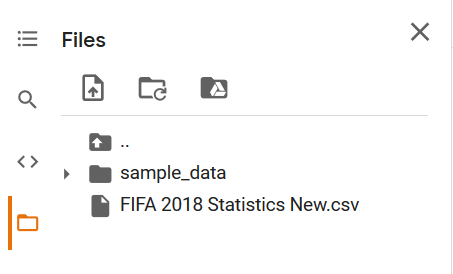

In [ ]:
print(X_feature_names)

['Goal Scored', 'Ball Possession %', 'Attempts', 'On-Target', 'Off-Target', 'Blocked', 'Corners', 'Offsides', 'Free Kicks', 'Saves', 'Pass Accuracy %', 'Passes', 'Distance Covered (Kms)', 'Fouls Committed', 'Yellow Card', 'Yellow & Red', 'Red']


In [ ]:
Y_feature_names = [i for i in data.columns if data[i].dtype in [np.float]]

In [ ]:
print(Y_feature_names)

['Man of the Match']


In [ ]:
y = data['Man of the Match']
print(y)

0      1.0
1      0.0
2      0.0
3      1.0
4      0.0
      ... 
123    0.0
124    1.0
125    0.0
126    1.0
127    0.0
Name: Man of the Match, Length: 128, dtype: float64


**Task 1:** Add the code below, which will give you the numbers of those being nominated as the "man of the match" and those who are not.

**[2 Marks]**

In [ ]:
# Your code for task 1 [2 Marks]
print("For man of the match: {}, No man of the match: {}".format(sum(data["Man of the Match"] == 1.0),
sum(data["Man of the Match"] == 0.0)))

For man of the match: 64, No man of the match: 64


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
train_X, val_X, train_y, val_y = train_test_split(X, y, random_state=1)

**Task 2:** Give in percentages as well as in absolute numbers the size of the training and validation data, respectively. Provide evidence to your answer by writing the corresponding "print" programming statements.

**[4 Marks]**

In [ ]:
# Your code for task 2 [1 Mark]
# For the training dataset
print(train_X.shape)
print(train_y.shape)

# Percentage size of the training set.
# This applies to both the features and output
print(train_X.shape[0] / 128)

(96, 17)
(96,)
0.75


**Your answer for task 2 (size of training dataset):**  

**[1 Mark]**

In [ ]:
# Your code for task 2 [1 Mark]
# For the validation dataset
print(val_X.shape)
print(val_y.shape)

# Percentage size of the training set.
# This applies to both the features and output dataset
print(val_X.shape[0] / 128)

(32, 17)
(32,)
0.25


**Your answer for task 2 (size of validation dataset):**

**[1 Mark]**

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
model1 = DecisionTreeClassifier(random_state=1)
model1.fit(train_X, train_y)
y_pred1 = model1.predict(val_X)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

**Task 3:** Add below the code to measure the performance of all three classifiers in terms of confusion matrices and precision - recall - F1-score metrics.

**[6 Marks]**

In [ ]:
# Your code for task 3 regarding the first classifier [2 Marks]
cm = confusion_matrix(val_y, y_pred1)
print(cm)
classification_report(val_y, y_pred1)

[[9 7]
 [8 8]]


'              precision    recall  f1-score   support\n\n         0.0       0.53      0.56      0.55        16\n         1.0       0.53      0.50      0.52        16\n\n    accuracy                           0.53        32\n   macro avg       0.53      0.53      0.53        32\nweighted avg       0.53      0.53      0.53        32\n'

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model2 = RandomForestClassifier(random_state=1)
model2.fit(train_X, train_y)
y_pred2 = model2.predict(val_X)

In [ ]:
# Your code for task 3 regarding the second classifier [2 Marks]
cm = confusion_matrix(val_y, y_pred2)
print(cm)
classification_report(val_y, y_pred2)

[[10  6]
 [ 3 13]]


'              precision    recall  f1-score   support\n\n         0.0       0.77      0.62      0.69        16\n         1.0       0.68      0.81      0.74        16\n\n    accuracy                           0.72        32\n   macro avg       0.73      0.72      0.72        32\nweighted avg       0.73      0.72      0.72        32\n'

In [ ]:
from sklearn.ensemble import AdaBoostClassifier
model3 = AdaBoostClassifier(random_state=1)
model3.fit(train_X, train_y)
y_pred3 = model3.predict(val_X)

In [ ]:
# Your code for task 3 regarding the third classifier [2 Marks]
cm = confusion_matrix(val_y, y_pred2)
print(cm)
classification_report(val_y, y_pred2)


[[10  6]
 [ 3 13]]


'              precision    recall  f1-score   support\n\n         0.0       0.77      0.62      0.69        16\n         1.0       0.68      0.81      0.74        16\n\n    accuracy                           0.72        32\n   macro avg       0.73      0.72      0.72        32\nweighted avg       0.73      0.72      0.72        32\n'

**Task 4:** In the following, import the appropriate libraries and code for  studying and explaining the behaviour of the three classifiers in terms of the permutation importance algorithm, i.e., by ranking the most influential features for their outcomes. State the main difference in the behaviour of the three classifiers.

**Hint:** *You may reuse code from case study 4 (FIFA Statistics application)*.

**[8 Marks]**

In [ ]:
# Your code for task 4 [6 Marks]
!pip install eli5

     |████████████████████████████████| 112kB 7.9MB/s 


In [ ]:
import eli5

In [ ]:
from eli5.sklearn import PermutationImportance

In [ ]:
perm = PermutationImportance(model1, random_state=1).fit(val_X, val_y)

In [ ]:
eli5.show_weights(perm, feature_names = val_X.columns.tolist())

Weight,Feature
0.0437 ± 0.0500,Ball Possession %
0.0312 ± 0.0395,Goal Scored
0.0187 ± 0.0306,Off-Target
0.0187 ± 0.0306,Distance Covered (Kms)
0.0063 ± 0.0250,On-Target
0.0063 ± 0.1146,Free Kicks
0 ± 0.0000,Saves
0 ± 0.0000,Yellow & Red
0 ± 0.0000,Offsides
0 ± 0.0000,Blocked


In [ ]:
perm = PermutationImportance(model2, random_state=1).fit(val_X, val_y)

In [ ]:
eli5.show_weights(perm, feature_names = val_X.columns.tolist())

Weight,Feature
0.1375 ± 0.0637,Goal Scored
0.0187 ± 0.0306,On-Target
0.0063 ± 0.0612,Distance Covered (Kms)
0 ± 0.0000,Yellow & Red
0.0000 ± 0.0559,Attempts
0.0000 ± 0.0395,Blocked
0.0000 ± 0.0559,Corners
0 ± 0.0000,Offsides
0 ± 0.0000,Red
0.0000 ± 0.0685,Free Kicks


In [ ]:
perm = PermutationImportance(model3, random_state=1).fit(val_X, val_y)

In [ ]:
eli5.show_weights(perm, feature_names = val_X.columns.tolist())

Weight,Feature
0.0938 ± 0.0395,Blocked
0.0875 ± 0.0250,Goal Scored
0.0875 ± 0.0250,Pass Accuracy %
0.0688 ± 0.0468,Off-Target
0.0375 ± 0.0250,Ball Possession %
0.0312 ± 0.0884,Passes
0.0250 ± 0.0612,Corners
0.0187 ± 0.0306,On-Target
0.0187 ± 0.0306,Distance Covered (Kms)
0.0125 ± 0.0637,Free Kicks


Each of the classifiers use different influential feeatures to predict the man of the match award.
For DecisionTree the most influential features are; Ball Possession and Goal Scored
For RandomForest the most influential features are; Goal Scored
For AdaBoost Classifier the most influential features are; Blocked, Goal Scored, Pass Accuracy %, and Off-Target

**Your answer for task 4:**

**[2 Marks]**

**END of the programming assignment.**